# Extract transition and reward functions

In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
from old.value_iteration import value_iteration
from env.user_sim import UserSimEnv
import utils
import mdp_utils
import process_data as dp
import env.simulate as sim
from sklearn.cluster import KMeans
from morld.mo_pi import MOPolicyIteration
import ipywidgets as widgets
from ipywidgets import interact, fixed
import matplotlib.pyplot as plt
import plotly.express as px

seed = 42
np.random.seed(seed)

%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Python311\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1206, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1178, in _find_and_load
  File "<frozen importl

In [2]:
MAX_COUNT = 2
NUM_FEATURES = 3
NUM_VALS_PER_FEATURE = [3, 3, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 6
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CLUSTERS
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = 6
cluster_col = 'cluster_all'

In [28]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
save_folder = 'functions\\3'
filename = 'processed_samples.csv'
df = pd.read_csv(data_folder + filename)

action_file = 'functions\\3\\challenge_info.csv'
actions = pd.read_csv(data_folder + action_file)

In [29]:
possible_state_features = ['TIR', 'TIME_Q', 'GOOD', 'PAY', 'MOT']
reward_signals = ['time_spent', 'likedness', 'usefulness', 'difficulty']

# expert_score_cols = ['score_acceptance', 'score_distraction', 'score_problem_solving', 'score_social_support']
# expert_score_matrix = actions[expert_score_cols].values


# action_categories = actions['category_id'].values
df = df.merge(actions[['challenge_id', 'category', 'expert_score']], on='challenge_id', how='left')

cluster_vars = ['time_spent', 'likedness', 'usefulness', 'difficulty']

df.head()

,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,challenge_id,completed,likedness,difficulty,time_spent,usefulness,category_x,expert_score_x,category_y,expert_score_y
0,3862670812,1,7,7,6,6,6,SP7,1,0.0,0.0,0.0,1.0,social_support,0.66,social_support,0.66
1,2283685875,1,2,6,7,7,1,AF23,1,9.0,1.0,20.0,7.0,distraction,0.66,distraction,0.66
2,6560911656,1,5,5,7,3,4,AF23,1,8.0,1.0,23.0,5.0,distraction,0.66,distraction,0.66
3,1274210211,1,6,6,5,5,5,SP11,1,6.0,6.0,7.0,5.0,social_support,0.66,social_support,0.66
4,6071243457,1,4,7,7,5,7,PO15,1,8.0,1.0,1.0,6.0,problem_solving,1.00,problem_solving,1.00


In [36]:
def bin_around_center(df, feature, use_median=True):
    print(f"Original {feature} distribution:")
    print(df[feature].describe())
    center = df[feature].median() if use_median else df[feature].mean()
    conditions = [
        (df[feature] < center),  # Below -> 0
        (df[feature] == center), # At -> 1
        (df[feature] > center)   # Above -> 2
    ]
    choices = [0, 1, 2]
    return np.select(conditions, choices)

# Apply it
df['TIR_custom_bin'] = bin_around_center(df, 'GOOD', use_median=True)

print(f"Center value used: {df['TIR'].median()}")
print(df['TIR_custom_bin'].value_counts().sort_index())

Original GOOD distribution:
count    3423.000000
mean        4.349985
std         1.367648
min         1.000000
25%         4.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: GOOD, dtype: float64
Center value used: 4.0
TIR_custom_bin
0     743
1    1106
2    1574
Name: count, dtype: int64


In [34]:
# can we create equal sized bins for state features?
def create_bins(df, feature, num_bins):
    bins = pd.qcut(df[feature], q=num_bins, labels=False, duplicates='drop')
    return bins

def create_bins_cut(df, feature, num_bins):
    bins = pd.cut(df[feature], bins=num_bins, labels=False)
    return bins

for feature in possible_state_features:
    df[feature + '_bin_qcut'], bin_edges = pd.qcut(df[feature], q=3, retbins=True)
    print(f"{feature}_bin value counts:")
    print(df[feature + '_bin_qcut'].value_counts())
    # print bin edges
    print(f"{feature}_bin qcut edges:")
    print(bin_edges)

    # use cut instead of qcut
    df[feature + '_bin_cut'], bin_edges = pd.cut(df[feature], bins=3, retbins=True, include_lowest=True)
    print(f"{feature}_bin_cut value counts:")
    print(df[feature + '_bin_cut'].value_counts())
    print(f"{feature}_bin_cut edges:")
    print(bin_edges)
    print()



TIR_bin value counts:
TIR_bin_qcut
(0.999, 4.0]    2089
(5.0, 7.0]       707
(4.0, 5.0]       627
Name: count, dtype: int64
TIR_bin qcut edges:
[1. 4. 5. 7.]
TIR_bin_cut value counts:
TIR_bin_cut
(3.0, 5.0]      1627
(0.993, 3.0]    1089
(5.0, 7.0]       707
Name: count, dtype: int64
TIR_bin_cut edges:
[0.994 3.    5.    7.   ]

TIME_Q_bin value counts:
TIME_Q_bin_qcut
(0.999, 3.0]    1324
(4.0, 7.0]      1068
(3.0, 4.0]      1031
Name: count, dtype: int64
TIME_Q_bin qcut edges:
[1. 3. 4. 7.]
TIME_Q_bin_cut value counts:
TIME_Q_bin_cut
(3.0, 5.0]      1590
(0.993, 3.0]    1324
(5.0, 7.0]       509
Name: count, dtype: int64
TIME_Q_bin_cut edges:
[0.994 3.    5.    7.   ]

GOOD_bin value counts:
GOOD_bin_qcut
(0.999, 4.0]    1849
(4.0, 5.0]       903
(5.0, 7.0]       671
Name: count, dtype: int64
GOOD_bin qcut edges:
[1. 4. 5. 7.]
GOOD_bin_cut value counts:
GOOD_bin_cut
(3.0, 5.0]      2009
(0.993, 3.0]     743
(5.0, 7.0]       671
Name: count, dtype: int64
GOOD_bin_cut edges:
[0.994 3. 

In [56]:
samples = df
samples.to_csv(os.path.join(data_folder, save_folder, 'samples.csv'), index=False)

### Extract states

In [7]:
samples = pd.read_csv(os.path.join(data_folder, save_folder, 'samples.csv'))


In [12]:
actions_clustered, _, _ = dp.cluster_actions(actions, cluster_vars, num_clusters=6)

In [49]:
state_features = ['TIR', 'TIME_Q', 'GOOD']
num_vals_per_feature = [3] * len(state_features)

df, initial_distribution = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df.head()

Reference Means per Time Bin:
Bin 0 Mean: 1.0000 minutes
Bin 1 Mean: 4.0000 minutes
Bin 2 Mean: 31.0000 minutes
Time rating percentiles:
33.333333333333336th percentile: 1.0000
66.66666666666667th percentile: 5.0000
100.0th percentile: 300.0000


,user_id,day_number,MOT,PAY,challenge_id,completed,likedness,difficulty,time_spent,usefulness,...,s_next,cluster_all,count,s_count_next,s_count,r_diversity,c_idx,s_idx,sp_idx,r_time
0,3862670812,1,7,6,SP7,1,0.0,0.0,0.0,1.0,...,"[1, 2, 2]",5,"[0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0]",1.0,0,26,17,0.500000
1,2283685875,1,6,1,AF23,1,9.0,1.0,20.0,7.0,...,"[2, 0, 2]",4,"[0, 0, 0, 0, 1, 0]","[0, 0, 0, 0, 1, 0]","[0, 0, 0, 0, 0, 0]",1.0,0,8,20,0.177419
2,6560911656,1,5,4,AF23,1,8.0,1.0,23.0,5.0,...,"[0, 0, 2]",4,"[0, 0, 0, 0, 1, 0]","[0, 0, 0, 0, 1, 0]","[0, 0, 0, 0, 0, 0]",1.0,0,11,2,-0.500000
3,1274210211,1,6,5,SP11,1,6.0,6.0,7.0,5.0,...,"[1, 1, 2]",0,"[1, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",1.0,0,22,14,-0.375000
4,6071243457,1,7,7,PO15,1,8.0,1.0,1.0,6.0,...,"[0, 1, 2]",1,"[0, 1, 0, 0, 0, 0]","[0, 1, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",1.0,0,14,5,0.375000


[[-0.28781095  0.08515689  0.80315466  0.432892  ]
 [-0.34647739 -1.11712377 -1.1680098   0.56958846]
 [ 0.54995781  1.42425456  1.03909782 -0.75771205]
 [-0.45591535  0.22542602 -0.09010649 -0.96602003]
 [ 3.77136257  1.31664331  0.93338057 -0.30420898]
 [ 1.68407804  0.53505554  0.36757966  1.39155796]]


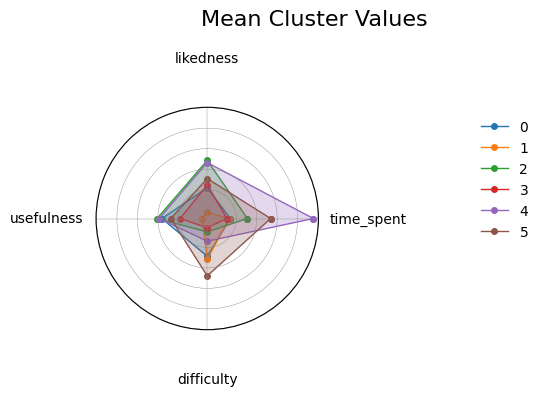

In [14]:
from radar import radar_chart
stats = actions_clustered.groupby('cluster_all')[cluster_vars].agg(['mean', 'count'])
means_df = stats.xs('mean', level=1, axis=1)
means = means_df[cluster_vars].values
print(means)
radar_chart(cluster_vars, means, groups=means_df.index.astype(str).tolist(), title='Mean Cluster Values', legend_position=(2,1))
plt.show()

## Learn transition and reward functions

### Estimate completion probability
For each $(u,a)$ pair we want to estimate the completion probability. To do this we cluster the actions based on perceived usefulness.

In [25]:
df = df.merge(actions_clustered[['action_id'] + [var + '_cluster' for var in cluster_vars]], on='action_id', how='left')


In [27]:
obj_to_cluster = {
    "obs_time": "obs_time_cluster",
    "obs_liked": "obs_liked_cluster",
    "obs_pu": "obs_pu_cluster",
    "r_diversity": "cluster_all",
    "r_expert": "action_id",
}
nO = len(obj_to_cluster)
NUM_ACTIONS = 104
P_c_clustered_all_actions = mdp_utils.compute_completion_probabilities_clustered(df, 'cluster_all', NUM_USER_STATES, NUM_ACTIONS, num_clusters=NUM_CLUSTERS, use_clusters=False)
R_clustered_all_actions = mdp_utils.compute_rewards_clustered(df, 
                                          P_c_clustered_all_actions, 
                                          obj_to_cluster, 
                                          NUM_USER_STATES, 
                                          NUM_COUNT_STATES, 
                                          NUM_ACTIONS, 
                                          nO, 
                                          action_categories,
                                          num_clusters=NUM_CLUSTERS,
                                          count_cluster=cluster_col,
                                          use_clusters=False)
P_clustered_all_actions = mdp_utils.compute_transition_probabilities_clustered(df, 
                                                                    NUM_USER_STATES, 
                                                                    NUM_ACTIONS, 
                                                                    'cluster_all', 
                                                                    num_clusters=NUM_CLUSTERS, 
                                                                    use_clusters=False)

print("P shape:", P_clustered_all_actions.shape)  # Should be (nU, nA, nU)
print("R shape:", R_clustered_all_actions.shape)  # Should be (nU, nC, nA, nO)

env_cl_all = mo_gym.make('user_env', num_actions=NUM_ACTIONS, 
                 num_objectives = 5, 
                 expert_score_matrix=expert_score_matrix, 
                 transition_probs=P_clustered_all_actions, 
                 completion_probs=P_c_clustered_all_actions,
                 reward_matrix=R_clustered_all_actions, 
                 action_categories=action_categories,
                 MAX_COUNT=MAX_COUNT)

P shape: (27, 104, 27)
R shape: (27, 729, 104, 5)


TypeError: UserSimEnv.__init__() got an unexpected keyword argument 'expert_score_matrix' was raised from the environment creator for user_env with kwargs ({'num_actions': 104, 'num_objectives': 5, 'expert_score_matrix': array([[0.66666667, 0.        , 0.        , 0.33333333],
       [1.        , 0.        , 0.        , 0.        ],
       [0.66666667, 0.        , 0.        , 0.33333333],
       [0.66666667, 0.        , 0.        , 0.        ],
       [0.66666667, 0.        , 0.33333333, 0.        ],
       [1.        , 0.        , 0.        , 0.        ],
       [1.        , 0.        , 0.33333333, 0.        ],
       [0.66666667, 0.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        , 0.33333333],
       [1.        , 0.        , 0.        , 0.        ],
       [0.66666667, 0.        , 0.        , 0.33333333],
       [0.66666667, 0.        , 0.    

In [ ]:
same_cluster = {
    "obs_time": "category_id",
    "obs_liked": "category_id",
    "obs_pu": "category_id",
    "r_diversity": "category_id",
    "r_expert": "category_id",
}
action_categories = actions[cluster_col].values
nO = len(obj_to_cluster)
n_clusters = 4
P_c_clustered = mdp_utils.compute_completion_probabilities_clustered(df, 'category_id', NUM_USER_STATES, NUM_ACTIONS, num_clusters=n_clusters, use_clusters=True)
R_clustered = mdp_utils.compute_rewards_clustered(df, 
                                          P_c_clustered, 
                                          same_cluster, 
                                          NUM_USER_STATES, 
                                          NUM_COUNT_STATES, 
                                          NUM_ACTIONS, 
                                          nO, 
                                          action_categories,
                                          num_clusters=n_clusters,
                                          count_cluster='category_id',
                                          use_clusters=True)
P_clustered = mdp_utils.compute_transition_probabilities_clustered(df, 
                                                                    NUM_USER_STATES, 
                                                                    NUM_ACTIONS, 
                                                                    'category_id', 
                                                                    num_clusters=n_clusters, 
                                                                    use_clusters=True)

print("P shape:", P_clustered.shape)  # Should be (nU, nA, nU)
print("R shape:", R_clustered.shape)  # Should be (nU, nC, nA, nO)

env_cl_cat = mo_gym.make('user_env', num_actions=n_clusters, 
                 num_objectives = 5, 
                 expert_score_matrix=expert_score_matrix, 
                 transition_probs=P_clustered, 
                 completion_probs=P_c_clustered,
                 reward_matrix=R_clustered, 
                 action_categories=np.array([0,1,2,3]),
                 MAX_COUNT=MAX_COUNT)

P shape: (27, 4, 27)
R shape: (27, 243, 4, 5)


In [ ]:
same_cluster = {
    "obs_time": "cluster_all",
    "obs_liked": "cluster_all",
    "obs_pu": "cluster_all",
    "r_expert": "cluster_all",
    "r_diversity": "cluster_all",
}
nO = len(same_cluster)
n_clusters = 5
P_c_clustered = mdp_utils.compute_completion_probabilities_clustered(df, 'cluster_all', NUM_USER_STATES, NUM_ACTIONS, num_clusters=n_clusters, use_clusters=True)
R_clustered = mdp_utils.compute_rewards_clustered(df, 
                                          P_c_clustered, 
                                          same_cluster, 
                                          NUM_USER_STATES, 
                                          NUM_COUNT_STATES, 
                                          NUM_ACTIONS, 
                                          nO, 
                                          action_categories,
                                          num_clusters=n_clusters,
                                          count_cluster=cluster_col,
                                          use_clusters=True)
P_clustered = mdp_utils.compute_transition_probabilities_clustered(df, 
                                                                    NUM_USER_STATES, 
                                                                    NUM_ACTIONS, 
                                                                    'cluster_all', 
                                                                    num_clusters=n_clusters, 
                                                                    use_clusters=True)

print("P shape:", P_clustered.shape)  # Should be (nU, nA, nU)
print("R shape:", R_clustered.shape)  # Should be (nU, nC, nA, nO)

env_cl = mo_gym.make('user_env', num_actions=n_clusters, 
                 num_objectives = nO, 
                 expert_score_matrix=expert_score_matrix, 
                 transition_probs=P_clustered, 
                 completion_probs=P_c_clustered,
                 reward_matrix=R_clustered, 
                 action_categories=np.array([i for i in range(n_clusters)]),
                 MAX_COUNT=MAX_COUNT)

P shape: (27, 5, 27)
R shape: (27, 243, 5, 5)


In [ ]:
P_c = mdp_utils.compute_completion_probabilities(df, NUM_USER_STATES, NUM_ACTIONS)
R = mdp_utils.compute_rewards(df, P_c, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, nO, obj_to_cluster.keys())
P = mdp_utils.compute_transition_probabilities(df, NUM_USER_STATES, NUM_ACTIONS)
print("P shape:", P.shape)  # Should be (nU, nA, nU)
print("R shape:", R.shape)  # Should be (nU, nC, nA, nO)

env_all = mo_gym.make('user_env', num_actions=NUM_ACTIONS, 
                 num_objectives = 5, 
                 expert_score_matrix=expert_score_matrix, 
                 transition_probs=P, 
                 completion_probs=P_c,
                 reward_matrix=R, 
                 action_categories=action_categories,
                 MAX_COUNT=MAX_COUNT)

P shape: (27, 104, 27)
R shape: (27, 243, 104, 5)


### Learn transition function
Our state consists of a stochastic part: tiredness, time available, and motivation. We thus need to learn the transition probabilities for these states and the actions.

$T(s,a,s') = \frac{N(s,a,s')}{N(s,a)}$ 

In [ ]:
# save_folder = data_folder + save_folder
# if not os.path.exists(save_folder):
#     os.makedirs(save_folder)

# filename = os.path.join(save_folder, 'reward_matrix.npy')
# np.save(filename, reward_matrix)
# filename = os.path.join(save_folder, 'transition_probs.npy')
# np.save(filename, transition_probs_array)
# filename = os.path.join(save_folder, 'completion_probs.npy')
# np.save(filename, completion_probs_array)

In [ ]:
# random simulation for each environment
NUM_USERS = 100
NUM_TIMESTEPS = 28
NUM_OBJECTIVES = 5

simulation_results = []
policy_names = []

envs = [env_all, env_cl_all, env_cl_cat, env_cl]
env_names = ['All Actions', 'Clustered All Actions', 'Clustered by Category', 'Clustered by All Variables']
for env, name in zip(envs, env_names):
    print(f"Simulating environment: {name}")
    weights = 1/env.unwrapped.nO * np.ones(env.unwrapped.nO)  # equal weights for all objectives
    vi_agent = MOPolicyIteration(id=0, env=env.unwrapped, weights=weights, gamma=0.7, scalarization='linear')
    vi_agent.train(max_eval_iters=5)
    vi_agent.evaluate()
    policy = vi_agent.policy_table
    print(f"Policy for {name}:", policy)
    print(f"Expected return for {name}:", vi_agent.expected_return)
    sim_res = sim.simulate(env, NUM_USERS, policy, verbose=False, T=NUM_TIMESTEPS, num_vals=NUM_VALS, max_count=MAX_COUNT)
    simulation_results.append(sim_res)
    policy_names.append(name)
objectives = ['obs_time', 'obs_liked', 'obs_pu', 'r_diversity', 'r_expert']
sim.interactive_plot_objective(simulation_results, policy_names, objectives, NUM_USERS, NUM_TIMESTEPS, NUM_OBJECTIVES)

Simulating environment: All Actions


Running policy iteration with weights: [0.2 0.2 0.2 0.2 0.2]
Policy converged after 6 iterations.
Policy for All Actions: [10 80 38 ... 61 61 61]
Expected return for All Actions: [2.04031435 2.77502829 2.78812034 3.01949897 0.96913701]
Simulating environment: Clustered All Actions
Running policy iteration with weights: [0.2 0.2 0.2 0.2 0.2]
Policy converged after 5 iterations.
Policy for Clustered All Actions: [ 46  46  46 ... 101 101 101]
Expected return for Clustered All Actions: [1.37292281 1.26346209 1.59351924 1.71305343 0.65037499]
Simulating environment: Clustered by Category
Running policy iteration with weights: [0.2 0.2 0.2 0.2 0.2]
Policy converged after 7 iterations.
Policy for Clustered by Category: [1 1 1 ... 2 2 2]
Expected return for Clustered by Category: [1.03635397 1.37230772 1.73759569 2.10183126 0.57680033]
Simulating environment: Clustered by All Variables
Running policy iteration with weights: [0.2 0.2 0.2 0.2 0.2]
Policy converged after 5 iterations.
Policy for 

interactive(children=(Dropdown(description='Objective:', options=(('obs_time', 0), ('obs_liked', 1), ('obs_pu'…